In [1]:
## Imports

from copy import deepcopy
from datetime import datetime, timedelta
import numpy as np
import random

from stonesoup.types.detection import TrueDetection, Clutter
from stonesoup.types.state import State, GaussianState
from stonesoup.types.array import StateVector, CovarianceMatrix
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel, ConstantVelocity)
from stonesoup.models.measurement.nonlinear import (
    CartesianToElevationBearingRange, Cartesian2DToBearing)
from stonesoup.sensor.radar.radar import RadarElevationBearingRange
from stonesoup.sensor.sensor import SimpleSensor
from stonesoup.models.clutter import ClutterModel
from stonesoup.platform.base import FixedPlatform
from stonesoup.simulator.simple import MultiTargetGroundTruthSimulator
from stonesoup.simulator.platform import PlatformDetectionSimulator
from stonesoup.plotter import Plotter, Dimension
from itertools import tee


In [2]:
## Params

start_time = datetime.now()
np.random.seed(739)
random.seed(567)

initial_number_targets = 4
num_steps = 200


In [3]:
## Clutter model (shared spatial params, independent instances per sensor)

params = (
    (-10_000, 10_000),   # x [m]
    (-10_000, 10_000),   # y [m]
    (  8_000, 10_000),   # z [m]
)

radar_clutter_model = ClutterModel(
    clutter_rate=0.5,
    distribution=np.random.default_rng().uniform,
    dist_params=params
)

rfdoa_clutter_model = ClutterModel(
    clutter_rate=0.5,
    distribution=np.random.default_rng().uniform,
    dist_params=params
)


In [4]:
## Radar sensor  — measures elevation, bearing, range

radar = RadarElevationBearingRange(
    ndim_state=6,
    position_mapping=(0, 2, 4),   # x, y, z in state [x,vx,y,vy,z,vz]
    noise_covar=CovarianceMatrix(np.diag([
        np.deg2rad(0.15)**2,   # elevation noise [rad²]
        np.deg2rad(0.15)**2,   # bearing  noise [rad²]
        25.0**2,               # range    noise [m²]
    ])),
    clutter_model=radar_clutter_model,
)


In [5]:
## RF-DOA sensor — measures bearing only (passive, angle-of-arrival)

# Cartesian2DToBearing maps [x,vx,y,vy,z,vz] → [bearing]  (1-D measurement)
# noise_covar must be 1×1

_rfdoa_meas_model = Cartesian2DToBearing(
    ndim_state=6,
    mapping=(0, 2),                               # x-index, y-index
    noise_covar=np.array([[np.deg2rad(1.0)**2]])  # 1×1 covariance
)


class RFDOASensor(SimpleSensor):
    """Passive bearing-only RF Direction-of-Arrival sensor."""

    @property
    def measurement_model(self):
        return _rfdoa_meas_model

    def is_detectable(self, state, measurement_model=None):
        return True

    def is_clutter_detectable(self, detection):
        return True

    def measure(self, ground_truths, noise=True, **kwargs):
        detections = set()                           # NOTE: 'detections', not 'detection'

        for truth in ground_truths:
            meas = _rfdoa_meas_model.function(truth, noise=noise)
            detections.add(TrueDetection(
                state_vector=meas,
                groundtruth_path=truth,              # NOTE: correct kwarg name
                timestamp=truth.timestamp,
                measurement_model=_rfdoa_meas_model,
            ))

        if self.clutter_model:
            # ClutterModel needs measurement_model set before calling function()
            self.clutter_model.measurement_model = _rfdoa_meas_model
            detections |= self.clutter_model.function(ground_truths, **kwargs)

        return detections


rfdoa_sensor = RFDOASensor()

print('RF-DOA sensor:', rfdoa_sensor)
print('measurement_model:', rfdoa_sensor.measurement_model)


RF-DOA sensor: RFDOASensor(
    rotation_offset=None,
    mounting_offset=None,
    movement_controller=None,
    seed=None,
    clutter_model=None)
measurement_model: Cartesian2DToBearing(
    ndim_state=6,
    mapping=(0, 2),
    noise_covar=[[0.00030462]],
    seed=None,
    rotation_offset=StateVector([[0.],
                                 [0.],
                                 [0.]]),
    translation_offset=StateVector([[0.],
                                    [0.]]))


In [6]:
## Platforms — one fixed platform per sensor (mirrors reference notebook)
# Both are co-located at origin (0,0,0).

platform_state_radar = State(StateVector([[0],[0],[0]]), start_time)
platform_state_rfdoa = State(StateVector([[0],[0],[0]]), start_time)

radar_platform = FixedPlatform(
    states=platform_state_radar,
    position_mapping=(0, 1, 2),
    sensors=[radar],
)

rfdoa_platform = FixedPlatform(
    states=platform_state_rfdoa,
    position_mapping=(0, 1, 2),
    sensors=[rfdoa_sensor],
)

print('Radar platform sensors :', [type(s).__name__ for s in radar_platform.sensors])
print('RFDOA platform sensors :', [type(s).__name__ for s in rfdoa_platform.sensors])


Radar platform sensors : ['RadarElevationBearingRange']
RFDOA platform sensors : ['RFDOASensor']


In [7]:
## Ground truth simulator
# State layout: [x, vx, y, vy, z, vz]
# Targets start near (0, 0, 9000 m).

transition_model = CombinedLinearGaussianTransitionModel([
    ConstantVelocity(0.5),
    ConstantVelocity(0.5),
    ConstantVelocity(0.1),
])

initial_target_state = GaussianState(
    state_vector=StateVector([[0],[0],[0],[0],[9000],[0]]),
    covar=CovarianceMatrix(np.diag([2000, 50, 2000, 50, 100, 1])),
)

gt_simulator = MultiTargetGroundTruthSimulator(
    transition_model=transition_model,
    initial_state=initial_target_state,
    timestep=timedelta(seconds=1),
    initial_number_targets=initial_number_targets,
    number_steps=num_steps,
    birth_rate=0.05,
    death_probability=0.02,
)


In [8]:
## Detection simulators
# One PlatformDetectionSimulator per sensor — same pattern as reference notebook.
# tee each simulator into:  *_plotting  (consumed in the plot loop below)
#                           *_detector  (reserved for tracker, consumed later)

gt_sims = tee(gt_simulator, 2)

radar_sim = PlatformDetectionSimulator(
    groundtruth=gt_sims[0],
    platforms=[radar_platform],
)
radar_plotting, radar_detector = tee(radar_sim, 2)

rfdoa_sim = PlatformDetectionSimulator(
    groundtruth=gt_sims[1],
    platforms=[rfdoa_platform],
)
rfdoa_plotting, rfdoa_detector = tee(rfdoa_sim, 2)


In [9]:
## Collect detections and truths for plotting
# zip over the two *_plotting branches — same pattern as reference notebook.

radar_detections = set()
rfdoa_detections = set()
truths           = set()

for (time, r_dets), (_, rf_dets) in zip(radar_plotting, rfdoa_plotting):
    truths.update(gt_simulator.groundtruth_paths)
    radar_detections.update(r_dets)
    rfdoa_detections.update(rf_dets)

# Separate true detections from clutter within each set
radar_true    = {d for d in radar_detections  if isinstance(d, TrueDetection)}
radar_clutter = {d for d in radar_detections  if isinstance(d, Clutter)}
rfdoa_true    = {d for d in rfdoa_detections  if isinstance(d, TrueDetection)}
rfdoa_clutter = {d for d in rfdoa_detections  if isinstance(d, Clutter)}

print(f'Ground truth paths  : {len(truths)}')
print(f'Radar  true dets    : {len(radar_true)}')
print(f'Radar  clutter      : {len(radar_clutter)}')
print(f'RFDOA  true dets    : {len(rfdoa_true)}')
print(f'RFDOA  clutter      : {len(rfdoa_clutter)}')


Ground truth paths  : 16
Radar  true dets    : 865
Radar  clutter      : 86
RFDOA  true dets    : 865
RFDOA  clutter      : 0


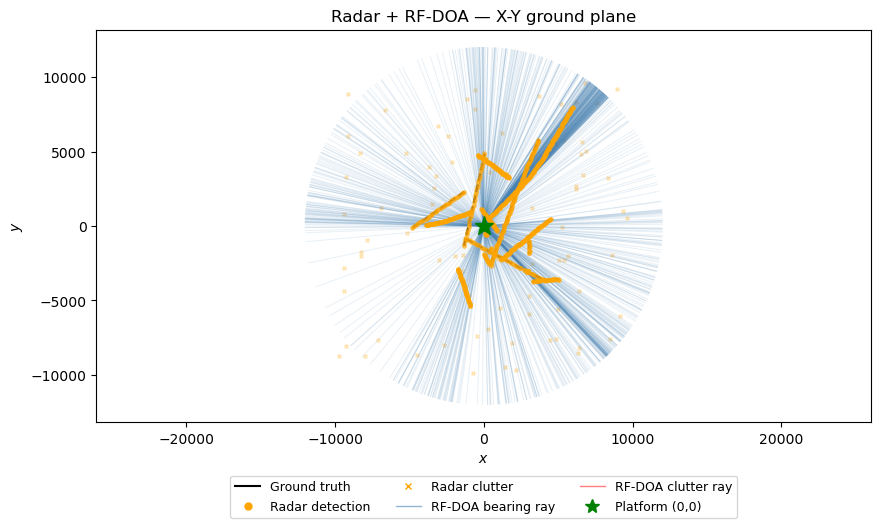

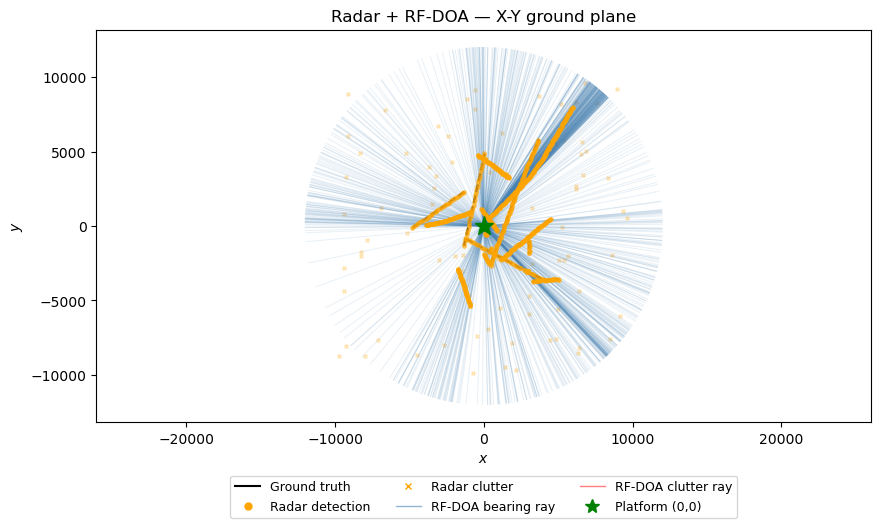

In [10]:
## Plot — Stone Soup Plotter (2-D, X-Y plane)
#
# Radar detections are in measurement space (elevation, bearing, range).
# plot_measurements() needs Cartesian indices — but our radar detections
# are in spherical coords, so we use the Stone Soup plotter only for
# ground truths and RFDOA, and add radar points manually after converting.
#
# RF-DOA detections are bearing-only: we draw a ray from the platform
# origin in the measured direction (length = 12 km) to visualise them.

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ── Stone Soup plotter for ground truths
plotter = Plotter(dimension=Dimension.TWO)
plotter.plot_ground_truths(truths, [0, 2], color='black')

# ── Radar detections: convert (el, bearing, range) → (x, y) and overlay
def spherical_to_xy(det):
    sv = det.state_vector
    el, az, r = float(sv[0]), float(sv[1]), float(sv[2])
    x = r * np.cos(el) * np.cos(az)
    y = r * np.cos(el) * np.sin(az)
    return x, y

if radar_true:
    rxs, rys = zip(*[spherical_to_xy(d) for d in radar_true])
    plotter.ax.scatter(rxs, rys, s=6, c='orange', alpha=0.5,
                       zorder=3, label='Radar detections')

if radar_clutter:
    cxs, cys = zip(*[spherical_to_xy(d) for d in radar_clutter])
    plotter.ax.scatter(cxs, cys, s=6, c='orange', marker='x', alpha=0.3,
                       label='Radar clutter')

# ── RF-DOA: draw bearing rays from origin
RAY_LEN = 12_000   # arbitrary display length [m]

for det in rfdoa_true:
    b = float(det.state_vector[0])
    plotter.ax.plot([0, RAY_LEN * np.cos(b)], [0, RAY_LEN * np.sin(b)],
                    color='steelblue', alpha=0.12, linewidth=0.7)

for det in rfdoa_clutter:
    b = float(det.state_vector[0])
    plotter.ax.plot([0, RAY_LEN * np.cos(b)], [0, RAY_LEN * np.sin(b)],
                    color='red', alpha=0.08, linewidth=0.6)

# ── Platform marker
plotter.ax.plot(0, 0, 'g*', markersize=14, zorder=5)

# ── Legend
legend_elems = [
    Line2D([0],[0], color='black',     lw=1.5,              label='Ground truth'),
    Line2D([0],[0], color='orange',    lw=0, marker='o', ms=5, label='Radar detection'),
    Line2D([0],[0], color='orange',    lw=0, marker='x', ms=5, label='Radar clutter'),
    Line2D([0],[0], color='steelblue', lw=1, alpha=0.6,     label='RF-DOA bearing ray'),
    Line2D([0],[0], color='red',       lw=1, alpha=0.5,     label='RF-DOA clutter ray'),
    Line2D([0],[0], color='green',     lw=0, marker='*', ms=10, label='Platform (0,0)'),
]
# put legend below plot like reference notebook
pos = plotter.ax.get_position()
plotter.ax.set_position([pos.x0, pos.y0 + 0.15, pos.width, pos.height * 0.85])
plotter.ax.legend(handles=legend_elems, loc='upper center',
                  bbox_to_anchor=(0.5, -0.12), ncol=3, fontsize=9)
plotter.ax.set_title('Radar + RF-DOA — X-Y ground plane')

from IPython.display import display
display(plotter.fig)
